# STARFlow — Pretrained Components Explorer

This notebook lets you load and experiment with every external pretrained component used in STARFlow.

| Cell section | Component | Status | Download size |
|---|---|---|---|
| 1 | Setup | — | — |
| 2 | VAE encoder | Frozen | ~335 MB |
| 3 | VAE decoder finetuning | To finetune | same checkpoint |
| 4 | FLAN-T5-XL text encoder | Frozen | ~9.4 GB |
| 5 | Gemma LLM backbone (optional) | To finetune | ~5–9 GB |
| 6 | Full pipeline walkthrough | — | — |

**Sources:** Gu et al. (2025) *STARFlow*, Appendix B.1–B.3; `model_setup.py`

## Cell 1 — Setup

In [1]:
import sys, os

# Add the pretrained_components folder to the Python path
# Adjust this path to wherever you saved the .py files
COMPONENTS_DIR = os.path.join(os.getcwd(), 'pretrained_components')
if COMPONENTS_DIR not in sys.path:
    sys.path.insert(0, COMPONENTS_DIR)

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Using device: cpu
PyTorch version: 2.9.1+cpu


---
## Cell 2 — VAE: frozen encoder

The encoder maps pixel images to continuous latent tokens.  
It is **frozen throughout all STARFlow training** — the flow learns to model whatever distribution the encoder produces (Gu et al., 2025 §3.3).

In [2]:
from load_vae import load_vae, encode, decode, pil_to_tensor, tensor_to_pil, print_latent_shapes

vae = load_vae(device=DEVICE, freeze_encoder=True)
print_latent_shapes()

c:\Users\sarpg\projects\master_thesis\STARFlow\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading VAE from stabilityai/sd-vae-ft-mse ...


c:\Users\sarpg\projects\master_thesis\STARFlow\Lib\site-packages\huggingface_hub\utils\_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


  Encoder frozen  (requires_grad=False)
  Encoder params : 34.2M
  Decoder params : 49.5M  (trainable)
  Total VAE      : 83.7M
  Scaling factor : 0.18215
  Latent channels: 4
  Spatial downsample: 8x  (256px image → 32x32 latent)

STARFlow latent sequence lengths (patch_size=1, Appendix B.1):
   256x256 → 32x32 latent →  1024 tokens x 4 channels
   512x512 → 64x64 latent →  4096 tokens x 4 channels
  1024x1024 → 128x128 latent → 16384 tokens x 4 channels


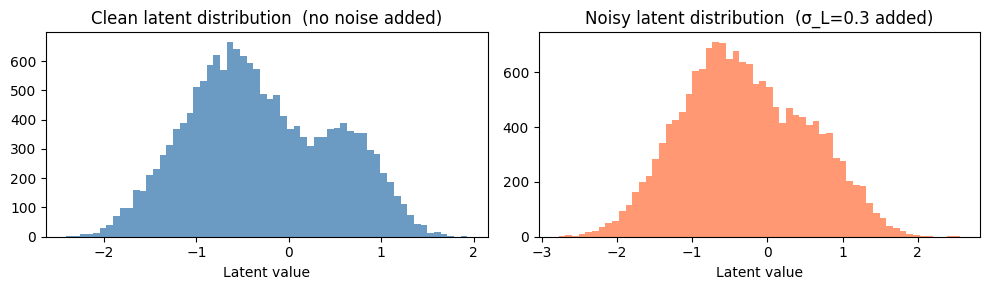

Clean latent — mean: -0.2993, std: 0.7742
Noisy latent — mean: -0.2974, std: 0.8302


In [3]:
# ── Visualise latent statistics ──────────────────────────────────────────────
# Generate a batch of random 'images' and see what their latents look like.
# With a real image the latent should cluster around 0 after scaling.

dummy_batch = torch.randn(4, 3, 256, 256).to(DEVICE)   # pretend images

latents_clean = encode(vae, dummy_batch, add_noise=False)   # clean latents
latents_noisy = encode(vae, dummy_batch, add_noise=True)    # + sigma_L=0.3 noise

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(latents_clean.cpu().numpy().flatten(), bins=60, color='steelblue', alpha=0.8)
axes[0].set_title('Clean latent distribution  (no noise added)')
axes[0].set_xlabel('Latent value')
axes[1].hist(latents_noisy.cpu().numpy().flatten(), bins=60, color='coral', alpha=0.8)
axes[1].set_title(f'Noisy latent distribution  (σ_L={0.3} added)')
axes[1].set_xlabel('Latent value')
plt.tight_layout()
plt.show()

print(f'Clean latent — mean: {latents_clean.mean():.4f}, std: {latents_clean.std():.4f}')
print(f'Noisy latent — mean: {latents_noisy.mean():.4f}, std: {latents_noisy.std():.4f}')

In [4]:
# ── Round-trip with a real image ─────────────────────────────────────────────
# Set IMAGE_PATH to a real .jpg or .png file on your machine.
# If you leave it as None the cell is skipped.

IMAGE_PATH = None   # e.g. r'C:\Users\you\Pictures\photo.jpg'

if IMAGE_PATH:
    img = Image.open(IMAGE_PATH)
    x   = pil_to_tensor(img, size=256).to(DEVICE)

    latent_clean = encode(vae, x, add_noise=False)
    latent_noisy = encode(vae, x, add_noise=True)
    recon_clean  = decode(vae, latent_clean)
    recon_noisy  = decode(vae, latent_noisy)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    for ax, t, title in zip(axes,
                            [x, recon_clean, recon_noisy],
                            ['Original', 'Reconstructed (clean)', 'Reconstructed (noisy, σ=0.3)']):
        ax.imshow(tensor_to_pil(t))
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()
    print('The noisy reconstruction should be blurrier.')
    print('This is exactly why the decoder needs finetuning (Gu et al., 2025 Appendix B.3).')
else:
    print('Set IMAGE_PATH to a real image to run the round-trip test.')

Set IMAGE_PATH to a real image to run the round-trip test.


---
## Cell 3 — VAE decoder finetuning setup

After main flow training, the decoder is separately finetuned to reconstruct clean pixels from noisy latents.  
Only `vae.decoder` and `vae.post_quant_conv` receive gradients during this stage.

In [5]:
from decoder_finetune_setup import (
    setup_decoder_finetuning,
    noisy_latent_from_image,
    decode_latent,
    decoder_reconstruction_loss,
    build_decoder_optimizer,
)

# Re-load the VAE with all params unfrozen first,
# then let setup_decoder_finetuning manage the freezing
from load_vae import load_vae
vae_ft = load_vae(device=DEVICE, freeze_encoder=False)

trainable_params, frozen, trainable = setup_decoder_finetuning(vae_ft)
optimizer = build_decoder_optimizer(trainable_params, lr=1e-4)

Loading VAE from stabilityai/sd-vae-ft-mse ...
  Encoder params : 34.2M
  Decoder params : 49.5M  (trainable)
  Total VAE      : 83.7M
  Scaling factor : 0.18215
  Latent channels: 4
  Spatial downsample: 8x  (256px image → 32x32 latent)
Decoder finetuning setup:
  Frozen params    : 34.2M  (encoder + quant_conv)
  Trainable params : 49.5M  (decoder + post_quant_conv)


In [6]:
# ── Simulate one finetuning step ─────────────────────────────────────────────
x_clean  = torch.randn(2, 3, 256, 256).to(DEVICE)   # in a real run: real images

noisy_z  = noisy_latent_from_image(vae_ft, x_clean, sigma=0.3)
recon    = decode_latent(vae_ft, noisy_z)            # gradients flow here
losses   = decoder_reconstruction_loss(recon, x_clean)

optimizer.zero_grad()
losses['loss'].backward()
optimizer.step()

print(f'noisy_z shape : {tuple(noisy_z.shape)}')
print(f'recon shape   : {tuple(recon.shape)}')
print(f'L2 loss       : {losses["l2"].item():.4f}')
print('One decoder finetuning step completed.')
print('(LPIPS and GAN losses are stubs until those libraries are added)')

noisy_z shape : (2, 4, 32, 32)
recon shape   : (2, 3, 256, 256)
L2 loss       : 1.0263
One decoder finetuning step completed.
(LPIPS and GAN losses are stubs until those libraries are added)


---
## Cell 4 — FLAN-T5-XL text encoder

Encodes text captions into 128-token sequences of 2048-dimensional vectors.  
These are prepended as a prefix to the deep MetaBlock's input sequence.

> **Note:** First download is ~9.4 GB. Use `google/flan-t5-base` (768-dim) for faster testing — just remember to set `txt_dim=768` in your Model constructor.

In [7]:
from load_text_encoder import load_text_encoder, encode_text

# Change to 'google/flan-t5-xl' for the actual STARFlow model (9.4 GB)
TEXT_MODEL = 'google/flan-t5-base'   # smaller for quick testing (768-dim)

tokenizer, text_encoder, txt_dim = load_text_encoder(
    model_id=TEXT_MODEL,
    device=DEVICE,
)
print(f'\ntxt_dim = {txt_dim}  ← use this in Model(txt_dim={txt_dim}, ...)')

Loading text encoder from google/flan-t5-base ...
  (This may download several GB on first run)


c:\Users\sarpg\projects\master_thesis\STARFlow\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sarpg\.cache\huggingface\hub\models--google--flan-t5-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


TypeError: T5Model.__init__() got an unexpected keyword argument 'add_cross_attention'

In [ ]:
# ── Encode some captions ──────────────────────────────────────────────────────
captions = [
    'a corgi sitting on a beach at sunset',
    'a futuristic cityscape at night with neon lights',
    'a bowl of ramen with soft boiled egg',
]

embeddings = encode_text(tokenizer, text_encoder, captions, device=DEVICE)
print(f'Input: {len(captions)} captions')
print(f'Output shape: {tuple(embeddings.shape)}')
print(f'  → (batch={len(captions)}, seq=128, txt_dim={txt_dim})')

In [ ]:
# ── Visualise embedding similarity ───────────────────────────────────────────
# Average pool the 128 tokens into a single vector per caption,
# then compute cosine similarity. Semantically similar captions
# should have higher similarity.

pooled = embeddings.mean(dim=1)   # (3, txt_dim)
pooled = pooled / pooled.norm(dim=-1, keepdim=True)   # L2-normalise
sim    = (pooled @ pooled.T).cpu().numpy()            # (3, 3) cosine similarity

short_labels = [c[:30] + '...' for c in captions]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(sim, vmin=0, vmax=1, cmap='Blues')
ax.set_xticks(range(len(captions)))
ax.set_yticks(range(len(captions)))
ax.set_xticklabels(short_labels, rotation=20, ha='right', fontsize=8)
ax.set_yticklabels(short_labels, fontsize=8)
for i in range(len(captions)):
    for j in range(len(captions)):
        ax.text(j, i, f'{sim[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im)
ax.set_title('Cosine similarity between caption embeddings')
plt.tight_layout()
plt.show()

---
## Cell 5 — Gemma LLM backbone (optional)

The Gemma backbone replaces both the FLAN-T5 text encoder **and** the randomly-initialised deep top block.  
It is loaded from pretrained LLM weights and then finetuned end-to-end as part of the flow.

Requirements:
- `huggingface-cli login`  (Gemma requires accepting a licence)
- ~5–9 GB disk space depending on model size

In [ ]:
from load_llm_backbone import print_backbone_options, load_gemma_config

print_backbone_options()

In [ ]:
# Load config only (no weight download) to inspect the architecture
config, gemma_tokenizer = load_gemma_config('gemma2_2b')
print(f'\nGemma-2 2B config:')
print(f'  hidden_size      : {config.hidden_size}')
print(f'  num_hidden_layers: {config.num_hidden_layers}')
print(f'  num_attention_heads: {config.num_attention_heads}')

In [ ]:
# To load the FULL Gemma-2-2b weights, uncomment the lines below.
# This requires huggingface-cli login and ~5.4 GB of disk space.

# from load_llm_backbone import load_gemma_backbone
# gemma_model, gemma_tokenizer, metablock_kwargs = load_gemma_backbone(
#     model_name='gemma2_2b',
#     device=DEVICE,
#     dtype=torch.bfloat16,
# )
# print('\nMetaBlock kwargs for the top block:')
# for k, v in metablock_kwargs.items():
#     print(f'  {k} = {v}')

print('Gemma loading is commented out. Uncomment above to run.')

---
## Cell 6 — Full pipeline walkthrough

This cell traces the complete data flow from pixel image to training-ready noisy latent + text embedding — exactly what happens before each STARFlow training step.

In [ ]:
# ── Step-by-step STARFlow training input preparation ─────────────────────────

print('=== STARFlow training input pipeline ===\n')

# Step 1: start with a pixel image (B, 3, 256, 256) in [-1, 1]
x_pixels = torch.randn(2, 3, 256, 256).to(DEVICE).clamp(-1, 1)
print(f'Step 1  — pixel image   : {tuple(x_pixels.shape)}')

# Step 2: frozen VAE encoder → clean latent, then add STARFlow noise
with torch.no_grad():
    clean_latent = vae.encode(x_pixels).latent_dist.sample()
    clean_latent = clean_latent * vae.config.scaling_factor
noisy_latent = clean_latent + torch.randn_like(clean_latent) * 0.3
print(f'Step 2a — clean latent  : {tuple(clean_latent.shape)}  (scaling_factor={vae.config.scaling_factor})')
print(f'Step 2b — noisy latent  : {tuple(noisy_latent.shape)}  (+ σ_L=0.3 noise)')

# Step 3: frozen text encoder → token embeddings
batch_captions = ['a golden retriever playing in a park',
                  'a mountain landscape with snow at sunset']
text_emb = encode_text(tokenizer, text_encoder, batch_captions, device=DEVICE)
print(f'Step 3  — text embeddings: {tuple(text_emb.shape)}  (128 tokens, {txt_dim}-dim each)')

print()
print('These tensors are now ready to feed into the STARFlow model:')
print(f'  noisy_latent → patchify → flow blocks (x̃ in Gu et al. 2025 Eq. 6)')
print(f'  text_emb     → prepended as prefix to the deep block')
print(f'  clean_latent → used for MLE loss target (z = f(x̃))')

In [ ]:
# ── Inspect gradient flow ─────────────────────────────────────────────────────
# Confirm that the encoder has no gradients and the decoder does.

print('Gradient check:')
enc_grads = any(p.requires_grad for p in vae.encoder.parameters())
dec_grads = any(p.requires_grad for p in vae.decoder.parameters())
txt_grads = any(p.requires_grad for p in text_encoder.parameters())

print(f'  VAE encoder     requires_grad: {enc_grads}  (should be False)')
print(f'  VAE decoder     requires_grad: {dec_grads}  (should be True for finetuning)')
print(f'  Text encoder    requires_grad: {txt_grads}  (should be False)')